a series whose first difference su primera derivada es stacionaria y no autocorrelacion


            RANDOM PROCESS

    hacer derivada--
                   |
                   V

    es stacionaria su primera derivada 

                el FULLER

                    Y

    su primera derivada haces autocorrelacion            

                plot ACF

    after lag 0 no significant coefficients

                    |
                    |
                    V
                RANDOM PROCESS
 



no es estacionaria
no es seasonal

te mueves q veces hacia atras


In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df = pd.read_csv('data/widget_sales.csv')

In [3]:
df.describe()

,widget_sales
count,500.000000
mean,46.969858
std,15.382473
min,20.674946
25%,32.507149
50%,47.667536
75%,59.425693
max,82.922496


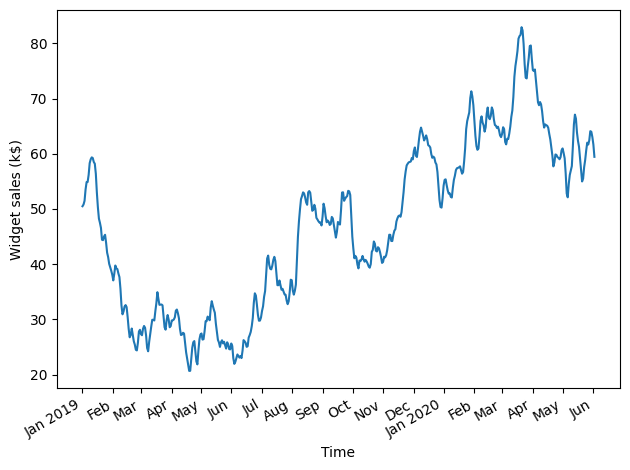

In [4]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('widget_sales.png', dpi=300)

In [5]:
adfuller(df['widget_sales'])

(np.float64(-1.5121662069359048),
 np.float64(0.5274845352272605),
 3,
 496,
 {'1%': np.float64(-3.4436029548776395),
  '5%': np.float64(-2.867384756137026),
  '10%': np.float64(-2.5698830308597813)},
 np.float64(1354.8017397952053))

In [6]:
widget_sales_diff = np.diff(df['widget_sales'], n=1)
widget_sales_diff

array([ 3.08778437e-01,  6.72264913e-01,  2.06447025e+00,  1.33088006e+00,
        1.20339627e-02,  1.29824354e+00,  2.11848518e+00,  6.94980715e-01,
        3.50263515e-01, -1.15955969e-01, -7.20037664e-01, -3.16219814e-01,
       -1.83523313e+00, -3.37428137e+00, -2.68869765e+00, -2.03636525e+00,
       -7.65986934e-01, -9.29050812e-01, -2.13525117e+00, -7.78317849e-02,
        6.69616481e-01,  3.04024165e-01, -1.43170569e+00, -1.80639763e+00,
       -8.06446318e-01, -1.21447806e+00, -6.26919424e-01, -6.07808547e-01,
       -7.19559165e-01, -1.04442259e+00,  1.22323411e+00,  1.47304116e+00,
       -5.14174976e-01, -1.33444091e-01, -7.97866508e-01, -6.43132216e-01,
       -2.13794598e+00, -3.02923008e+00, -1.58640725e+00,  5.17185878e-01,
        8.95046574e-01,  2.60123145e-01, -3.53776665e-01, -1.78420980e+00,
       -2.14084511e+00, -1.55205516e+00,  4.26594070e-01,  1.15683666e+00,
       -1.13664703e+00, -1.15956668e+00, -6.22318755e-01, -9.26270862e-01,
       -1.13078196e-01,  

In [7]:
adfuller(widget_sales_diff)

(np.float64(-10.576657780341959),
 np.float64(7.076922818587193e-19),
 2,
 496,
 {'1%': np.float64(-3.4436029548776395),
  '5%': np.float64(-2.867384756137026),
  '10%': np.float64(-2.5698830308597813)},
 np.float64(1350.640860630276))

In [15]:
#ma(0) ! random process

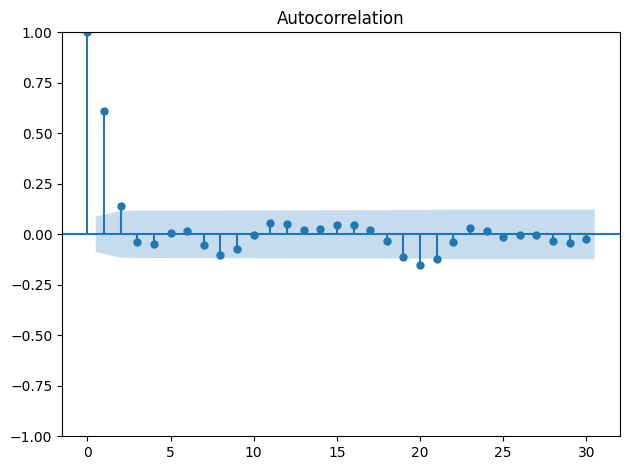

In [16]:
ax = plot_acf(
    widget_sales_diff, lags=30)
plt.tight_layout()

#ma(2) moving average process of order q

In [18]:
#forecast 50 timesteps into the future

In [22]:
df_diff = pd.DataFrame(
    {
        'widget_sales_diff':widget_sales_diff
    }
)

In [64]:
train_size = int(0.9 * len(df_diff))

#esque esta diferenciado por eso tiene 499

train = df_diff[:train_size]
test = df_diff[train_size:]

#!(test -> 450 - 499)


In [40]:
df_diff

,widget_sales_diff
0,0.308778
1,0.672265
2,2.064470
3,1.330880
4,0.012034
...,...
494,1.651336
495,-0.095290
496,-0.962187
497,-1.358097


In [45]:
df

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108
...,...
495,64.087371
496,63.992081
497,63.029894
498,61.671797


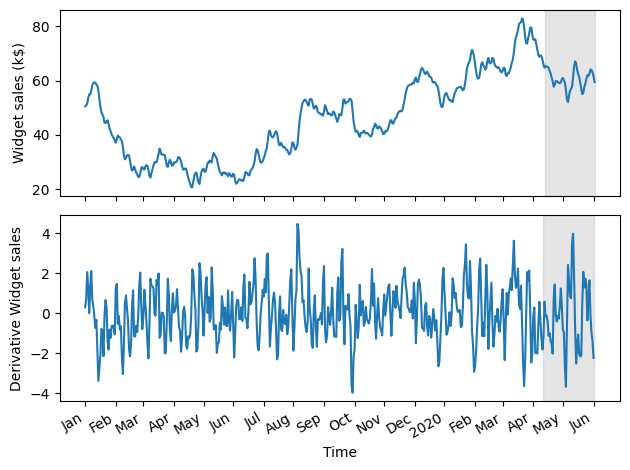

In [59]:
fig, (ax1, ax2) = plt.subplots(nrows=2,ncols=1,sharex=True)

ax1.plot(df['widget_sales'])
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 499, color='#808080', alpha=0.2)

ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Derivative Widget sales')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)

plt.xticks(
    ticks=[0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
)

fig.autofmt_xdate()
plt.tight_layout()

baseline u y ese se regresa

rolling forecasts

In [84]:
#!(test -> 450 - 499)

def rolling_forecast(df:pd.DataFrame, train_len:int, horizon:int, window:int, method:str):
    
    pass

TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, method='mean')
rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, method='last')
rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, method='MA')